Import libraries

In [27]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from dragonnet import Dragonnet
import sys
from pathlib import Path
project_root = Path("/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Tarnet/main_tarnet.ipynb")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from utils import seed_everything
from metrics import auuc, auqc, lift, krcc

In [28]:
%time train_df = pd.read_csv(r"/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/dataset/Hillstrom/Men/train_men.csv")
%time test_df =  pd.read_csv(r"/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/dataset/Hillstrom/Men/test_men.csv")
%time val_df = pd.read_csv(r"/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/dataset/Hillstrom/Men/val_men.csv")

CPU times: user 23.4 ms, sys: 6.99 ms, total: 30.4 ms
Wall time: 30.1 ms
CPU times: user 10.8 ms, sys: 5 ms, total: 15.8 ms
Wall time: 15.8 ms
CPU times: user 4.3 ms, sys: 2 ms, total: 6.29 ms
Wall time: 6.27 ms


In [29]:
in_features = ['recency', 'history_segment', 'history', 'mens', 'womens',
       'zip_code', 'newbie', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
label_feature = ['spend']
treatment_feature = ['treatment']

In [30]:
X_train = train_df[in_features].values.astype(float) # type: ignore
y_train = train_df[label_feature].values.astype(float) # type: ignore
t_train = train_df[treatment_feature].values.astype(float) # type: ignore

X_test = test_df[in_features].values.astype(float) # type: ignore
y_test = test_df[label_feature].values.astype(float) # type: ignore
t_test = test_df[treatment_feature].values.astype(float) # type: ignore

X_val = val_df[in_features].values.astype(float) # type: ignore
y_val = val_df[label_feature].values.astype(float) # type: ignore
t_val = val_df[treatment_feature].values.astype(float) # type: ignore

In [31]:
print('X_train[:10]', X_train[:1].astype(float))

X_train[:10] [[-0.21435131  1.6331766   1.0667411   0.90252386 -1.1010233   1.07039981
   1.00043033  2.70003843 -0.88552759 -0.88616046]]


In [32]:
print('y_train[:10]', y_train[:1].astype(float))

y_train[:10] [[0.]]


In [33]:
# Transform to tensor
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

x_men_train_t = to_tensor(X_train)
x_men_val_t = to_tensor(X_val)
x_men_test_t = to_tensor(X_test)

y_men_train_t = to_tensor(y_train).reshape(-1, 1)
y_men_val_t = to_tensor(y_val).reshape(-1, 1)
y_men_test_t = to_tensor(y_test).reshape(-1, 1)

# t_train/t_val/t_test cũng tương tự
t_men_train_t = to_tensor(t_train.astype(float)).reshape(-1, 1)
t_men_val_t = to_tensor(t_val.astype(float)).reshape(-1, 1)
t_men_test_t = to_tensor(t_test.astype(float)).reshape(-1, 1)

# Data loader
train_dataset = TensorDataset(x_men_train_t, t_men_train_t, y_men_train_t)
val_dataset = TensorDataset(x_men_val_t, t_men_val_t, y_men_val_t)
test_dataset = TensorDataset(x_men_test_t, t_men_test_t, y_men_test_t)

batch_size = 6400
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory = True)

print("-------------------------------------------------------------")
print("✅ Completed transform to tensor ✅")
print(f"Shape of train: x={x_men_train_t.shape}; y={y_men_train_t.shape}; t={t_men_train_t.shape}")
print(f"Shape of val: x={x_men_val_t.shape}; y={y_men_val_t.shape}; t={t_men_val_t.shape}")
print(f"Shape of test: x={x_men_test_t.shape}; y={y_men_test_t.shape}; t={t_men_test_t.shape}")

-------------------------------------------------------------
✅ Completed transform to tensor ✅
Shape of train: x=torch.Size([25567, 10]); y=torch.Size([25567, 1]); t=torch.Size([25567, 1])
Shape of val: x=torch.Size([4262, 10]); y=torch.Size([4262, 1]); t=torch.Size([4262, 1])
Shape of test: x=torch.Size([12784, 10]); y=torch.Size([12784, 1]); t=torch.Size([12784, 1])


In [34]:
epochs = 200
lr = 8e-5
wd = 1e-5
early_stop_metric = "qini"
ema = True
ema_alpha = 0.15
patience = 20
shared_dropout = 0
outcome_droupout = 0 
shared_hidden = 200
outcome_hidden = 100
early_stop_start = 30
activation = torch.nn.ReLU
print (f" epochs = {epochs}")
print (f" learning rate = {lr}")
print (f" weight decay = {wd}")
print (f" early stop = {early_stop_metric}")
print (f" use ema = {ema}")
print (f" ema alpha = {ema_alpha}")
print (f" patience = {patience}")
print (f" shared hidden = {shared_hidden}")
print (f" outcome hidden = {outcome_hidden}")
print (f" early stop start = {early_stop_start}")

 epochs = 200
 learning rate = 8e-05
 weight decay = 1e-05
 early stop = qini
 use ema = True
 ema alpha = 0.15
 patience = 20
 shared hidden = 200
 outcome hidden = 100
 early stop start = 30


Locked random seed: 412312
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/200 | Base Loss: 415.6790 | Tarreg Loss: 209.932663 | Total Loss: 625.6117 | Val Loss: 499.6456 | Raw Qini: 0.3841 | EMA Trend: 0.3841 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/200 | Base Loss: 538.3281 | Tarreg Loss: 270.890228 | Total Loss: 809.2184 | Val Loss: 499.6070 | Raw Qini: 0.4124 | EMA Trend: 0.3883 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/200 | Base Loss: 288.9145 | Tarreg Loss: 145.021072 | Total Loss: 433.9355 | Val Loss: 499.5670 | Raw Qini: 0.4328 | EMA Trend: 0.3950 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/200 | Base Loss: 262.9084 | Tarreg Loss: 132.678925 | Total Loss: 395.5873 | Val Loss: 499.5240 | Raw Qini: 0.4941 | EMA Trend: 0.4099 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/200 | Base Loss: 656.

/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Dragonnet/dragonnet.py:325: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


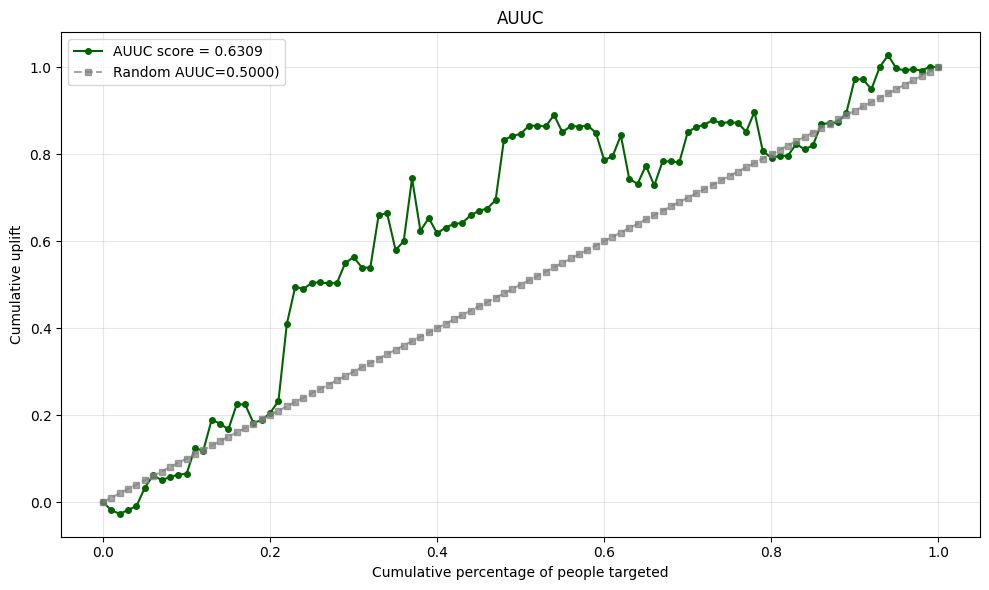

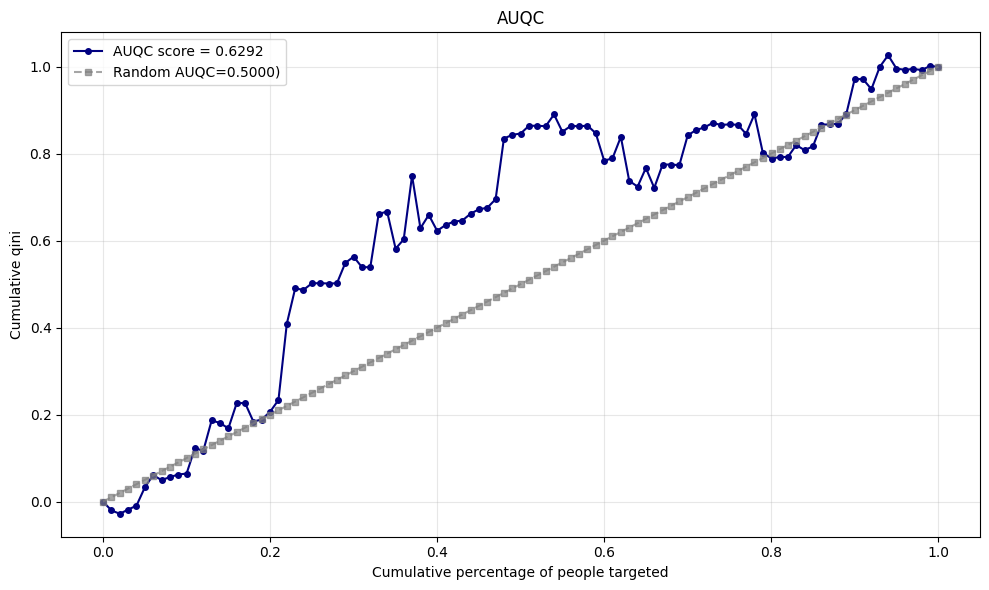

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.631
AUQC: 0.629
Lift: 1.103
KRCC: 0.061
ATE (predicted): 1.5972
ATE (true): 0.5874
ATE error: 1.0098


In [35]:
seed = 412312
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 42
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/200 | Base Loss: 423.6300 | Tarreg Loss: 213.007462 | Total Loss: 636.6375 | Val Loss: 499.1785 | Raw Qini: 0.6271 | EMA Trend: 0.6271 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/200 | Base Loss: 497.9247 | Tarreg Loss: 247.998306 | Total Loss: 745.9230 | Val Loss: 499.1404 | Raw Qini: 0.5890 | EMA Trend: 0.6214 | (patience: 1/20)
Epoch 3/200 | Base Loss: 516.2676 | Tarreg Loss: 257.695770 | Total Loss: 773.9634 | Val Loss: 499.1002 | Raw Qini: 0.5545 | EMA Trend: 0.6114 | (patience: 2/20)
Epoch 4/200 | Base Loss: 349.1908 | Tarreg Loss: 175.312851 | Total Loss: 524.5037 | Val Loss: 499.0565 | Raw Qini: 0.5344 | EMA Trend: 0.5998 | (patience: 3/20)
Epoch 5/200 | Base Loss: 357.7080 | Tarreg Loss: 179.001846 

/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Dragonnet/dragonnet.py:325: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


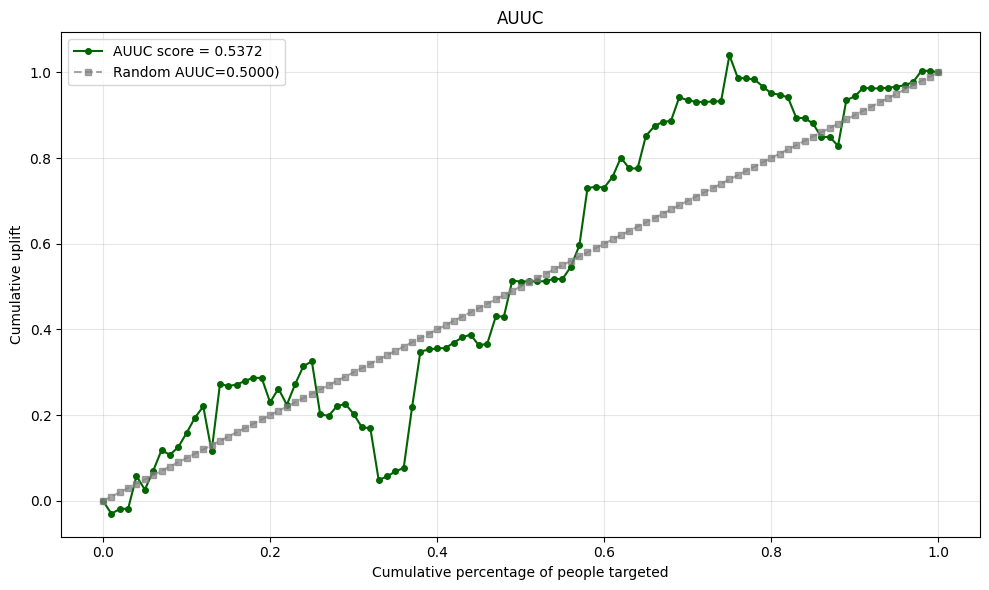

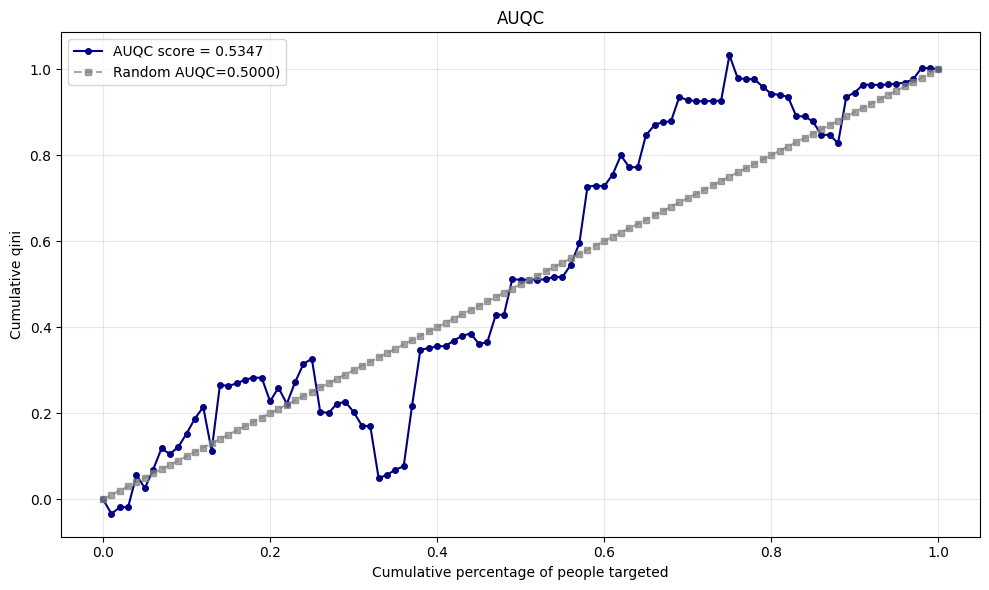

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.537
AUQC: 0.535
Lift: 0.398
KRCC: 0.078
ATE (predicted): 0.2774
ATE (true): 0.5874
ATE error: 0.3101


In [36]:
seed = 42
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 1874
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/200 | Base Loss: 422.1585 | Tarreg Loss: 223.303040 | Total Loss: 645.4615 | Val Loss: 499.4659 | Raw Qini: 0.3076 | EMA Trend: 0.3076 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/200 | Base Loss: 457.9420 | Tarreg Loss: 240.202209 | Total Loss: 698.1442 | Val Loss: 499.4416 | Raw Qini: 0.3421 | EMA Trend: 0.3127 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/200 | Base Loss: 564.2141 | Tarreg Loss: 293.322540 | Total Loss: 857.5366 | Val Loss: 499.4144 | Raw Qini: 0.3780 | EMA Trend: 0.3225 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/200 | Base Loss: 600.3710 | Tarreg Loss: 308.753693 | Total Loss: 909.1246 | Val Loss: 499.3836 | Raw Qini: 0.4066 | EMA Trend: 0.3351 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/200 | Base Loss: 406.71

/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Dragonnet/dragonnet.py:325: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


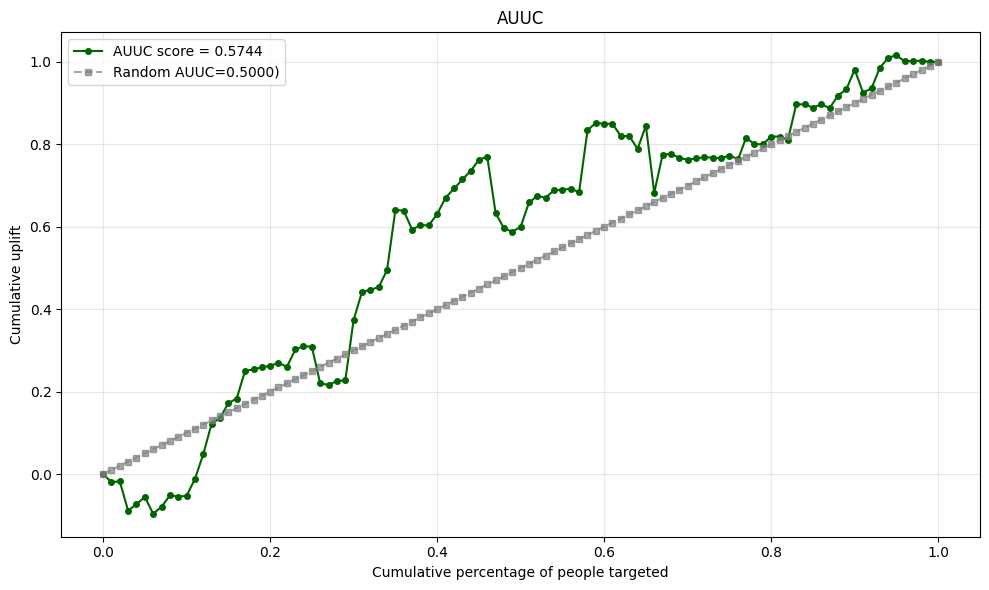

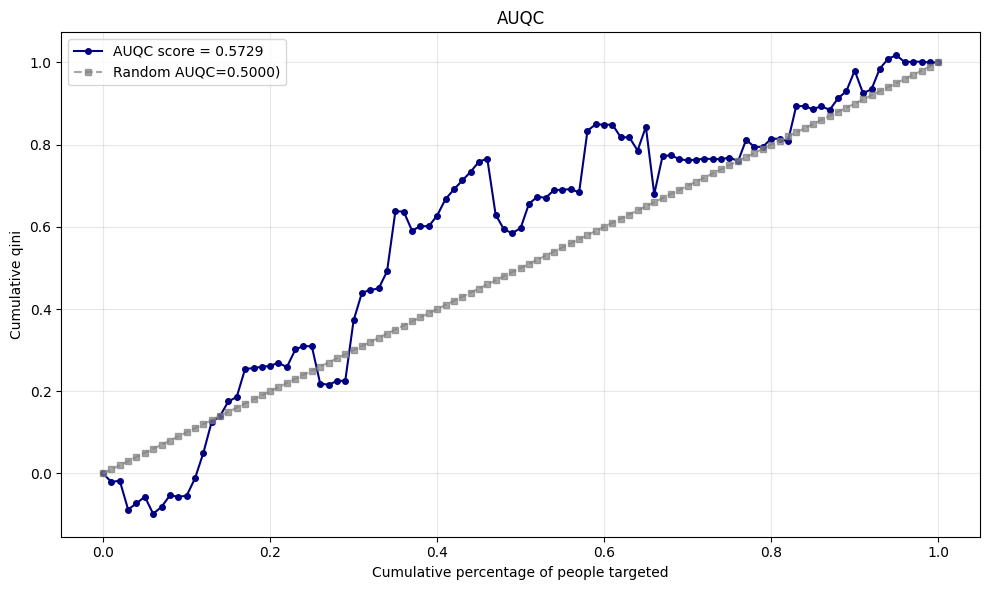

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.574
AUQC: 0.573
Lift: 0.732
KRCC: 0.096
ATE (predicted): 2.7620
ATE (true): 0.5874
ATE error: 2.1746


In [37]:
seed =1874
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 902745
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/200 | Base Loss: 408.9101 | Tarreg Loss: 208.860626 | Total Loss: 617.7707 | Val Loss: 499.2316 | Raw Qini: 0.2875 | EMA Trend: 0.2875 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/200 | Base Loss: 353.6792 | Tarreg Loss: 182.518173 | Total Loss: 536.1974 | Val Loss: 499.1954 | Raw Qini: 0.3045 | EMA Trend: 0.2900 | ⭐ NEW BEST (peak ≥ trend)
Epoch 3/200 | Base Loss: 373.3708 | Tarreg Loss: 192.371277 | Total Loss: 565.7421 | Val Loss: 499.1591 | Raw Qini: 0.3740 | EMA Trend: 0.3026 | ⭐ NEW BEST (peak ≥ trend)
Epoch 4/200 | Base Loss: 442.3158 | Tarreg Loss: 224.884323 | Total Loss: 667.2001 | Val Loss: 499.1209 | Raw Qini: 0.4553 | EMA Trend: 0.3255 | ⭐ NEW BEST (peak ≥ trend)
Epoch 5/200 | Base Loss: 483.

/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Dragonnet/dragonnet.py:325: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


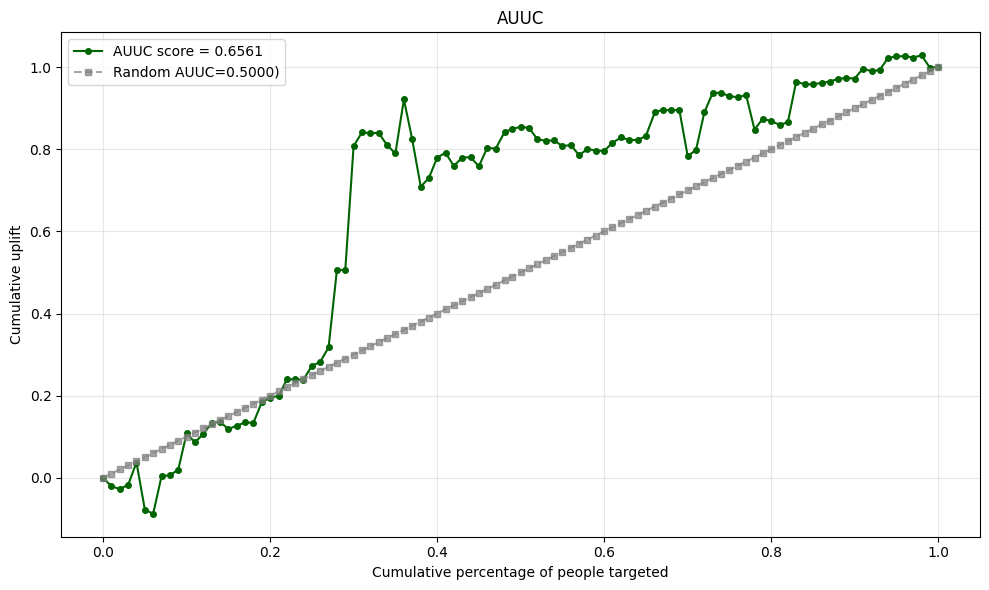

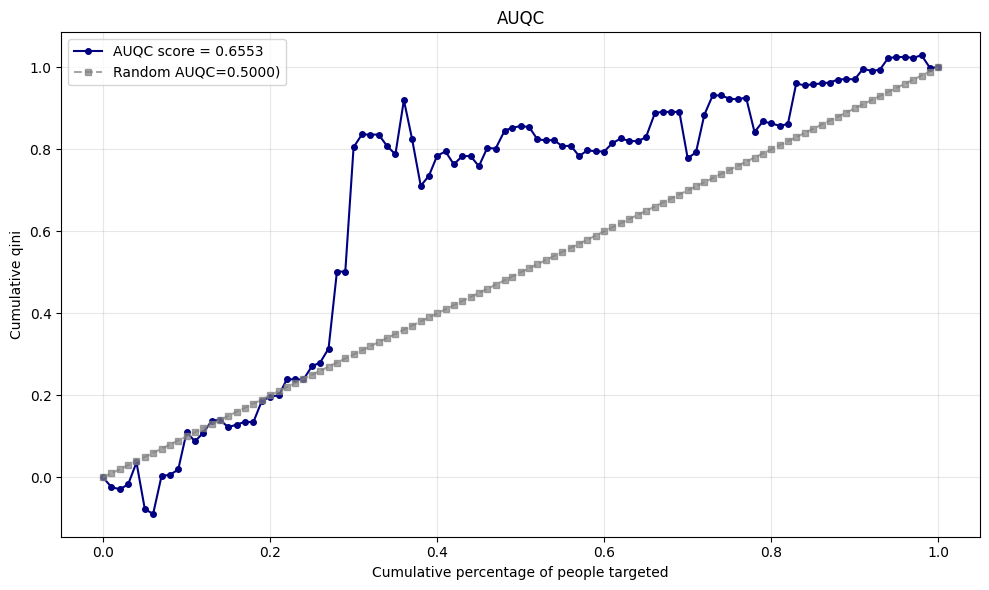

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.656
AUQC: 0.655
Lift: 1.581
KRCC: 0.044
ATE (predicted): 2.0208
ATE (true): 0.5874
ATE error: 1.4334


In [38]:
seed = 902745
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")

Locked random seed: 1
🔃🔃🔃Begin training Dragonnet🔃🔃🔃
📊 Early Stop Metric: QINI
📊 Early Stop Start Epoch: 31
📊 Strategy: Two-Stage EMA Filter (alpha=0.15)
   EMA filters noise spikes, Raw Qini determines peak height
   Select checkpoint: raw_qini is highest AND raw_qini >= ema_qini
Epoch 1/200 | Base Loss: 440.4043 | Tarreg Loss: 222.016739 | Total Loss: 662.4210 | Val Loss: 499.7888 | Raw Qini: 0.6053 | EMA Trend: 0.6053 | ⭐ NEW BEST (peak ≥ trend)
Epoch 2/200 | Base Loss: 336.6966 | Tarreg Loss: 170.977814 | Total Loss: 507.6744 | Val Loss: 499.7406 | Raw Qini: 0.5815 | EMA Trend: 0.6017 | (patience: 1/20)
Epoch 3/200 | Base Loss: 713.8142 | Tarreg Loss: 356.518524 | Total Loss: 1070.3328 | Val Loss: 499.6940 | Raw Qini: 0.5816 | EMA Trend: 0.5987 | (patience: 2/20)
Epoch 4/200 | Base Loss: 553.5903 | Tarreg Loss: 278.859100 | Total Loss: 832.4493 | Val Loss: 499.6455 | Raw Qini: 0.5873 | EMA Trend: 0.5970 | (patience: 3/20)
Epoch 5/200 | Base Loss: 437.9023 | Tarreg Loss: 219.286972 

/home/ducm/Benchmark-conversion-vs-revenue-uplift-modeling/Revenue/Dragonnet/dragonnet.py:325: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32, device=self.device)


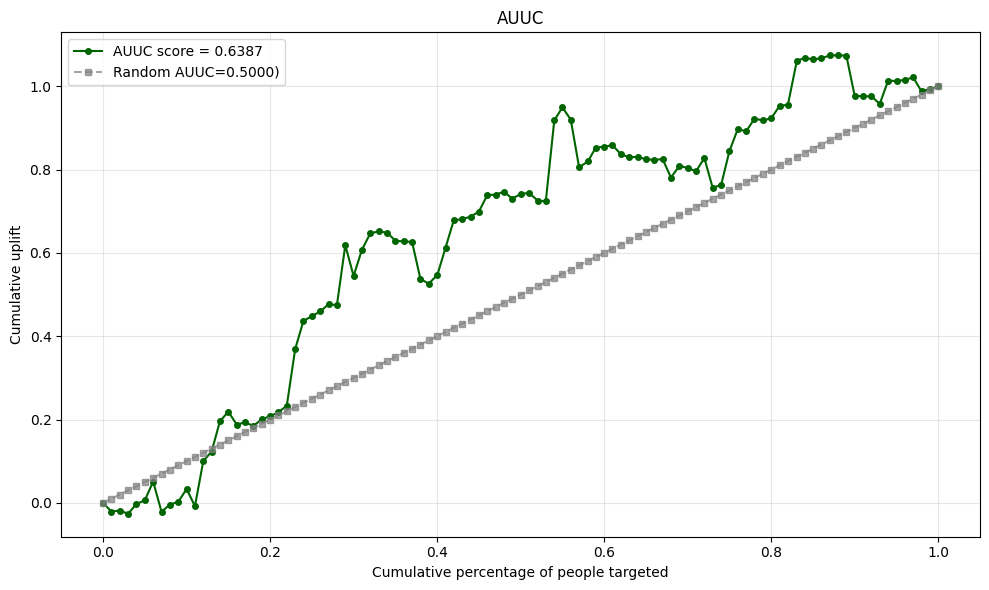

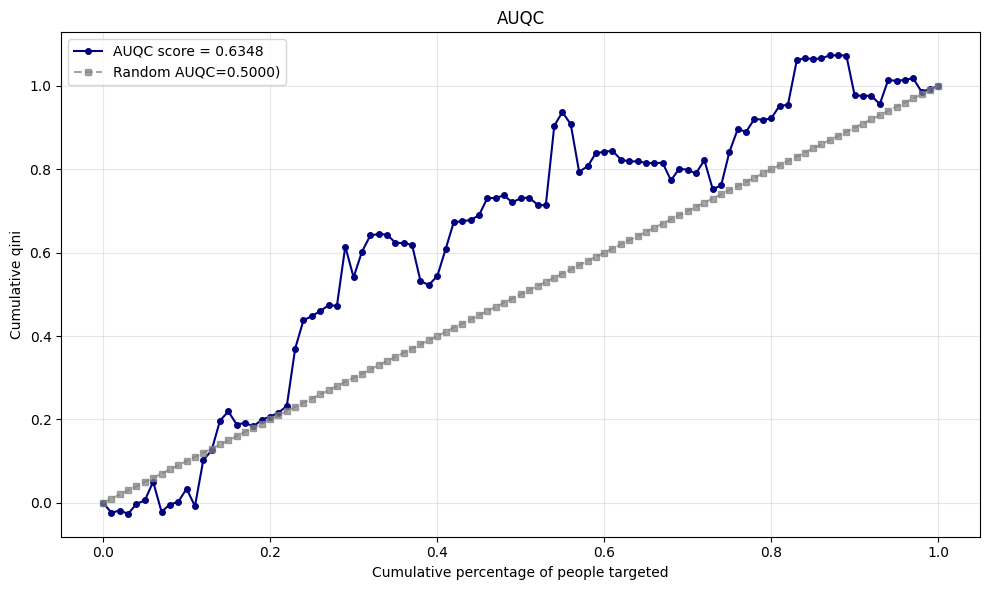

----------------------------------------
[ORIGINAL TEST SET]
AUUC: 0.639
AUQC: 0.635
Lift: 1.067
KRCC: 0.119
ATE (predicted): 1.2853
ATE (true): 0.5874
ATE error: 0.6979


In [39]:
seed = 1
seed_everything(seed)

dragonnet = Dragonnet(input_dim=x_men_train_t.shape[1], epochs=epochs, 
                      learning_rate=lr, 
                      weight_decay=wd,
                      use_ema=ema,
                      ema_alpha=ema_alpha,
                      patience=patience,
                      shared_hidden=shared_hidden,
                      outcome_hidden=outcome_hidden,
                      outcome_droupout=outcome_droupout,
                      shared_dropout=shared_dropout,
                      early_stop_metric=early_stop_metric,
                      early_stop_start_epoch=early_stop_start,
                      activation=activation
)
dragonnet.fit(train_loader, val_loader)

print ("Complete training")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Evaluate on ORIGINAL test set ===
print("=" * 50)
print("Evaluating on ORIGINAL test set 🔃🔃🔃")
x_men_test_t_on_device = x_men_test_t.to(device)
y0_pred, y1_pred, _, _ = dragonnet.predict(x_men_test_t_on_device)
uplift_pred = (y1_pred - y0_pred).cpu().numpy().flatten()
y_true = y_men_test_t.cpu().numpy().flatten()
t_true = t_men_test_t.cpu().numpy().flatten()

auuc_score = auuc(y_true, t_true, uplift_pred, bins=100, plot=True)
auqc_score = auqc(y_true, t_true, uplift_pred, bins=100, plot=True)
lift_score = lift(y_true, t_true, uplift_pred, h=0.3)
krcc_score = krcc(y_true, t_true, uplift_pred, bins=100)
ate_pred = uplift_pred.mean()
ate_true = y_true[t_true == 1].mean() - y_true[t_true == 0].mean()

print("-" * 40)
print("[ORIGINAL TEST SET]")
print(f"AUUC: {auuc_score:.3f}")
print(f"AUQC: {auqc_score:.3f}")
print(f"Lift: {lift_score:.3f}")
print(f"KRCC: {krcc_score:.3f}")
print(f"ATE (predicted): {ate_pred:.4f}")
print(f"ATE (true): {ate_true:.4f}")
print(f"ATE error: {abs(ate_pred - ate_true):.4f}")